In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")

In [3]:
# Synthetic sample data
np.random.seed(42)
n_samples = 200

x = np.random.uniform(-5, 5, size=n_samples)
noise = np.random.normal(0, 3.5, size=n_samples)
y = 2.8 * x + 7.5 + noise

df = pd.DataFrame({"x": x, "y": y})

# Fit scikit-learn model
X = df[["x"]]
y_target = df["y"]

model = LinearRegression()
model.fit(X, y_target)

# Predictions & residuals
df["y_pred"] = model.predict(X)
df["residuals"] = df["y"] - df["y_pred"]

# Metrics
ss_res = np.sum(df["residuals"]**2)
ss_tot = np.sum((df["y"] - np.mean(df["y"]))**2)
r2 = 1 - (ss_res / ss_tot)

print(f"Slope (coef_):       {model.coef_[0]:.3f}")
print(f"Intercept (intercept_): {model.intercept_:.3f}")
print(f"R² Score:            {r2:.3f}")

Slope (coef_):       2.773
Intercept (intercept_): 7.732
R² Score:            0.853


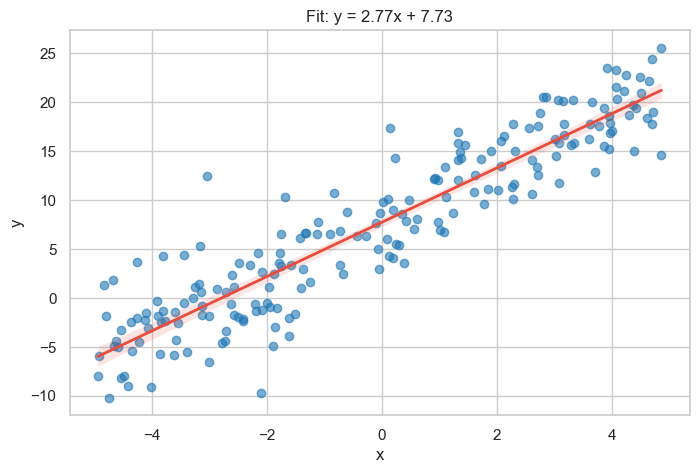

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="x",
    y="y",
    scatter_kws={"alpha": 0.6, "color": "#1f77b4"},
    line_kws={"color": "#e74c3c", "linewidth": 2}
)
plt.title(f"Fit: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}")
plt.show()

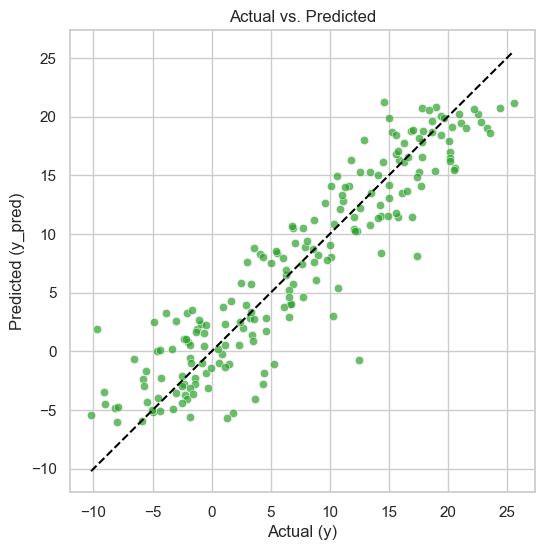

In [5]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x="y", y="y_pred", color="#2ca02c", alpha=0.7)

# 45-degree reference line
min_val = min(df["y"].min(), df["y_pred"].min())
max_val = max(df["y"].max(), df["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val], "--", color="black", linewidth=1.5)

plt.xlabel("Actual (y)")
plt.ylabel("Predicted (y_pred)")
plt.title("Actual vs. Predicted")
plt.show()